<a href="https://colab.research.google.com/github/farelagustin/2026_kecerdasan_buatan/blob/main/Jobsheet_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Latihan

1. Decision Tree

In [ ]:
import pandas as pd

# Membaca file iris.csv
iris = pd.read_csv('https://raw.githubusercontent.com/farelagustin/LatihanEDA/refs/heads/main/Iris.csv')

In [ ]:
# Melihat informasi dataset
iris.info()

# melihat informasi dataset pada 5 baris pertama
iris.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# menghilangkan kolom yang tidak penting
iris.drop('Id',axis=1,inplace=True)

In [ ]:
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]]
y = iris['Species']

# Membagi dataset menjadi data latih & data uji
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# membuat model Decision Tree
tree_model = DecisionTreeClassifier()

# Melatih model dengan menggunakan data latih
tree_model = tree_model.fit(X_train, y_train)

In [ ]:
# Evaluasi Model
from sklearn.metrics import accuracy_score

y_pred = tree_model.predict(X_test)

acc_secore = round(accuracy_score(y_pred, y_test), 3)

print('Accuracy: ', acc_secore)

Accuracy:  0.933


In [ ]:
# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print(tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])

Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print(tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])

Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(
    tree_model,
    out_file = "iris_tree.dot",
    feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica' ],
    rounded= True,
    filled =True)

2. Linear Regression

In [ ]:
import numpy as np

#buat data jumlah kamar
bedrooms = np.array([1,1,2,2,3,4,4,5,5,5])

#data harga rumah. asumsi dalam dollar
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000,85000, 90000])

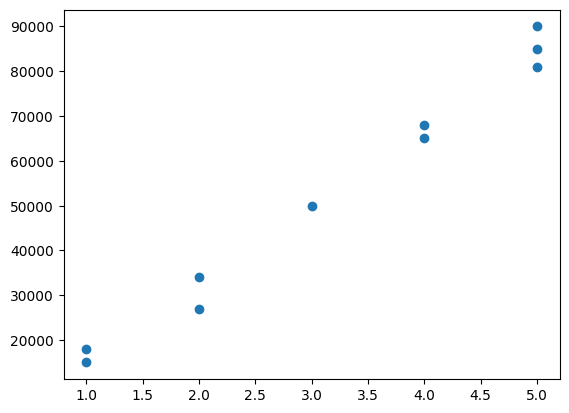

In [ ]:
# menampilkan scatter plot dari dataset
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(bedrooms, house_price)

In [ ]:
from sklearn.linear_model import LinearRegression

# latih model dengan Linear Regression.fit()
bedrooms = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)

LinearRegression()

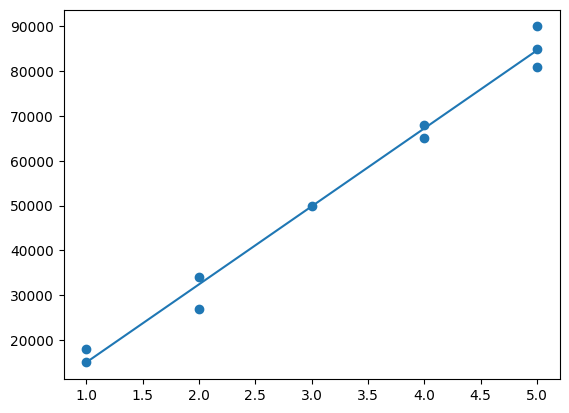

In [ ]:
# menampilkan plot hubungan antara jumlah kamar dengan harga rumah
plt.scatter(bedrooms, house_price)
plt.plot(bedrooms, linreg.predict(bedrooms))

In [ ]:
# Data testing
# Jumlah kamar yang ingin diprediksi harganya
X_test = np.array([[6], [7]])

# Melakukan prediksi harga kamar
y_pred = linreg.predict(X_test)

# Menampilkan hasil prediksi
for i in range(len(X_test)):
    print("Jumlah kamar:", X_test[i][0])
    print("Prediksi harga kamar:", y_pred[i])
    print()

Jumlah kamar: 6
Prediksi harga kamar: 102110.16949152542

Jumlah kamar: 7
Prediksi harga kamar: 119542.37288135593



In [ ]:
# uji akurasi model
linreg.score(X_test, y_pred)

1.0

3. Logistic Regression

In [ ]:
import pandas as pd

# membaca dataset dan mengubahnya menjadi dataframe
df = pd.read_csv('https://raw.githubusercontent.com/farelagustin/LatihanEDA/refs/heads/main/Social_Network_Ads.csv')

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
# drop kolom yang tidak diperlukan
data = df.drop(columns=['User ID'])

# jalankan proses one-hot encoding dengan pd.get_dummies()
data = pd.get_dummies(data)
data

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,False,True
1,35,20000,0,False,True
2,26,43000,0,True,False
3,27,57000,0,True,False
4,19,76000,0,False,True
...,...,...,...,...,...
395,46,41000,1,True,False
396,51,23000,1,False,True
397,50,20000,1,True,False
398,36,33000,0,False,True


In [ ]:
# pisahkan atribut dan label
predictions = ['Age' , 'EstimatedSalary' , 'Gender_Female' , 'Gender_Male']
X = data[predictions]
y = data['Purchased']

In [ ]:
# lakukan normalisasi terhadap data yang kita miliki
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_data = scaler.transform(X)
scaled_data = pd.DataFrame(scaled_data, columns= X.columns)
scaled_data.head()

,Age,EstimatedSalary,Gender_Female,Gender_Male
0,-1.781797,-1.490046,-1.020204,1.020204
1,-0.253587,-1.460681,-1.020204,1.020204
2,-1.113206,-0.785290,0.980196,-0.980196
3,-1.017692,-0.374182,0.980196,-0.980196
4,-1.781797,0.183751,-1.020204,1.020204


In [ ]:
from sklearn.model_selection import train_test_split

# bagi data menjadi train dan test untuk setiap atribut dan label
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)

In [ ]:
from sklearn import linear_model

# latih model dengan fungsi fit
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# uji akurasi model
model.score(X_test, y_test)

0.825

# Tugas Praktikum

1. Decision Tree dan Logistic Regression Base Model

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Gunakan sep=';' karena file csv dipisahkan oleh titik koma
df_iklan = pd.read_csv('iklan_sosmed.csv', sep=';')

# Drop kolom ID
df_iklan = df_iklan.drop(columns=['ID'])

# One-hot encoding untuk kolom Jenis_Kelamin
df_iklan = pd.get_dummies(df_iklan, columns=['Jenis_Kelamin'])

# Pisahkan atribut dan label
# Kolom sekarang meliputi: Umur, Gaji, Transaksi, Jenis_Kelamin_Pria, Jenis_Kelamin_Wanita
X_cls = df_iklan[['Umur', 'Gaji', 'Jenis_Kelamin_Pria', 'Jenis_Kelamin_Wanita']]
y_cls = df_iklan['Transaksi']

# Normalisasi data
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

# Split data latih dan data uji (80% Train, 20% Test)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls_scaled, y_cls, test_size=0.2, random_state=42)

# 1. Decision Tree Base Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_cls, y_train_cls)
dt_pred = dt_model.predict(X_test_cls)
dt_acc = accuracy_score(y_test_cls, dt_pred)

# 2. Logistic Regression Base Model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_cls, y_train_cls)
lr_pred = lr_model.predict(X_test_cls)
lr_acc = accuracy_score(y_test_cls, lr_pred)

2. Linear Regression

Nilai Ketepatan Model (R-squared) : 90.24%
Prediksi Kenaikan Gaji per Tahun  : 141357229.85


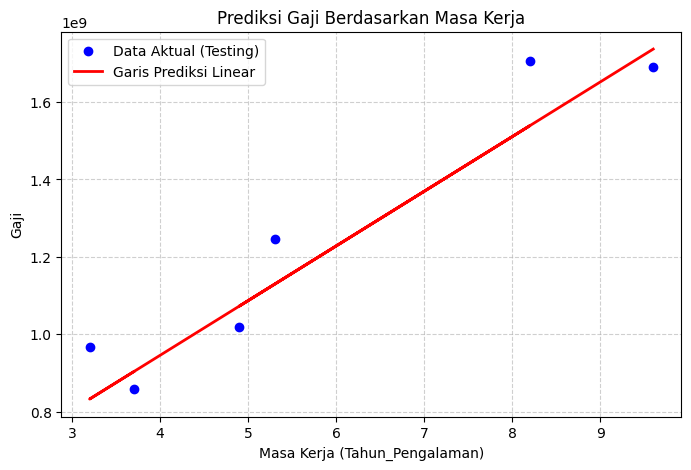

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Gunakan sep=';' sesuai format file datamu
df_gaji = pd.read_csv('Data_Gaji.csv', sep=';')

# Atribut (X) dan Label (y)
X_reg = df_gaji['Tahun_Pengalaman'].values.reshape(-1, 1)
y_reg = df_gaji['Gaji'].values

# Split Data (80% Train, 20% Test)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = lin_reg.predict(X_test_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Nilai Ketepatan Model (R-squared) : {r2 * 100:.2f}%")
print(f"Prediksi Kenaikan Gaji per Tahun  : {lin_reg.coef_[0]:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test_reg, y_test_reg, color='blue', label='Data Aktual (Testing)')
plt.plot(X_test_reg, y_pred_reg, color='red', linewidth=2, label='Garis Prediksi Linear')
plt.title('Prediksi Gaji Berdasarkan Masa Kerja')
plt.xlabel('Masa Kerja (Tahun_Pengalaman)')
plt.ylabel('Gaji')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

3. Perbandingan Akurasi Model

In [6]:
print("--- HASIL MODEL DASAR (TUGAS 3) ---")
print(f"Akurasi Decision Tree       : {dt_acc * 100:.2f}%")
print(f"Akurasi Logistic Regression : {lr_acc * 100:.2f}%\n")

--- HASIL MODEL DASAR (TUGAS 3) ---
Akurasi Decision Tree       : 85.00%
Akurasi Logistic Regression : 88.75%



4. Tuning Model

In [7]:
print("--- HASIL SETELAH TUNING (TUGAS 4) ---")

# Tuning Decision Tree
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train_cls, y_train_cls)
dt_tuned_acc = accuracy_score(y_test_cls, dt_grid.predict(X_test_cls))

print(f"Akurasi Tuned Decision Tree : {dt_tuned_acc * 100:.2f}%")
print(f"Parameter Terbaik DT        : {dt_grid.best_params_}\n")

# Tuning Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5)
lr_grid.fit(X_train_cls, y_train_cls)
lr_tuned_acc = accuracy_score(y_test_cls, lr_grid.predict(X_test_cls))

print(f"Akurasi Tuned Log Regression: {lr_tuned_acc * 100:.2f}%")
print(f"Parameter Terbaik LR        : {lr_grid.best_params_}")

--- HASIL SETELAH TUNING (TUGAS 4) ---
Akurasi Tuned Decision Tree : 91.25%
Parameter Terbaik DT        : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}

Akurasi Tuned Log Regression: 86.25%
Parameter Terbaik LR        : {'C': 0.01, 'solver': 'liblinear'}
